# Apprentissage (Linear Regression)

### Données linéaires bruitées

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(123)

In [3]:
m = 100
X = 2 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)

In [4]:
y

tensor([[  6.5170],
        [  2.9193],
        [  1.9042],
        [ -0.2922],
        [  5.5045],
        [  9.1572],
        [  1.4726],
        [  1.1690],
        [  8.5255],
        [ -1.8776],
        [  6.7305],
        [ -6.6179],
        [  4.3696],
        [ 14.4486],
        [ 10.8681],
        [  5.0125],
        [  2.3558],
        [ -2.4106],
        [  2.3820],
        [ 10.1068],
        [ 12.0653],
        [ 11.5824],
        [ 12.0824],
        [  1.8954],
        [  6.9610],
        [ -5.0074],
        [  9.0337],
        [ -2.9434],
        [ -3.6853],
        [  7.1876],
        [  1.3972],
        [-13.2601],
        [ -3.7441],
        [  4.5736],
        [ -8.2205],
        [ 10.5195],
        [  0.6847],
        [  0.3124],
        [  1.9526],
        [ -0.8365],
        [  9.7671],
        [ 13.1900],
        [  7.9716],
        [  2.0757],
        [  3.8340],
        [  3.2407],
        [  6.8091],
        [ -0.7178],
        [  7.0033],
        [ 11.9319],


# Exercice 1 : Trouver à la main les paramètres theta qui fonctionne

In [5]:
from ipywidgets import interact, FloatSlider

# Function to update plot
def plot_line(theta0, theta1):
    plt.figure(figsize=(8,5))
    plt.plot(X.numpy(), y.numpy(), "b.", label="Data")
    y_pred = theta0 + theta1 * X.numpy()
    plt.plot(X.numpy(), y_pred, "r-", linewidth=2, label=f"y = {theta0:.2f} + {theta1:.2f}x")
    plt.xlabel("$x$", fontsize=14)
    plt.ylabel("$y$", rotation=0, fontsize=14)
    plt.axis([0, 2, 0, 15])
    plt.legend()
    plt.show()

# Interactive sliders
interact(
    plot_line,
    theta0=FloatSlider(value=0, min=0, max=10, step=0.1),
    theta1=FloatSlider(value=0, min=0, max=10, step=0.1)
)

interactive(children=(FloatSlider(value=0.0, description='theta0', max=10.0), FloatSlider(value=0.0, descripti…

<function __main__.plot_line(theta0, theta1)>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

### Via Scikit-Learn (rappel)

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.0348725], dtype=float32), array([[2.9571738]], dtype=float32))

## Solution : Descente de Gradient

### Batch gradient descent

In [7]:
# Exercice 2

# Ajouter une colonne de 1 au vecteur X afin qu'on puisse le multiplier par theta -> Voir torch.hstack et torch.ones
# Définir : eta (learning rate) = 10 , nombre d'epochs = 100, thetas (initialisation) -> voir torch.randn
# Instancier une boucle où à chaque itération :
#   Calcul du gradient -> voir slide et torch.matmul ou l'opérateur @
#   Mise à jour de thetas -> voir slide

m = X.shape[0]

X_b = torch.hstack([X, torch.ones((m, 1))])
eta = 0.1
n_epochs = 100
thetas = torch.randn(2, 1)

for i in range(n_epochs):
    gradients = 2/m * torch.matmul(X_b.T, torch.matmul(X_b, thetas)-y)
    thetas = thetas - eta*gradients
    print(thetas)

tensor([[2.3308],
        [0.4951]])
tensor([[2.7609],
        [1.1912]])
tensor([[2.8628],
        [1.7562]])
tensor([[2.8945],
        [2.2101]])
tensor([[2.9096],
        [2.5739]])
tensor([[2.9197],
        [2.8652]])
tensor([[2.9272],
        [3.0984]])
tensor([[2.9332],
        [3.2851]])
tensor([[2.9380],
        [3.4346]])
tensor([[2.9418],
        [3.5543]])
tensor([[2.9449],
        [3.6501]])
tensor([[2.9473],
        [3.7269]])
tensor([[2.9493],
        [3.7883]])
tensor([[2.9509],
        [3.8374]])
tensor([[2.9521],
        [3.8768]])
tensor([[2.9531],
        [3.9083]])
tensor([[2.9539],
        [3.9336]])
tensor([[2.9546],
        [3.9538]])
tensor([[2.9551],
        [3.9699]])
tensor([[2.9555],
        [3.9829]])
tensor([[2.9558],
        [3.9932]])
tensor([[2.9561],
        [4.0015]])
tensor([[2.9563],
        [4.0082]])
tensor([[2.9565],
        [4.0135]])
tensor([[2.9566],
        [4.0178]])
tensor([[2.9567],
        [4.0212]])
tensor([[2.9568],
        [4.0239]])
t

tensor([[2.9572],
        [4.0349]])


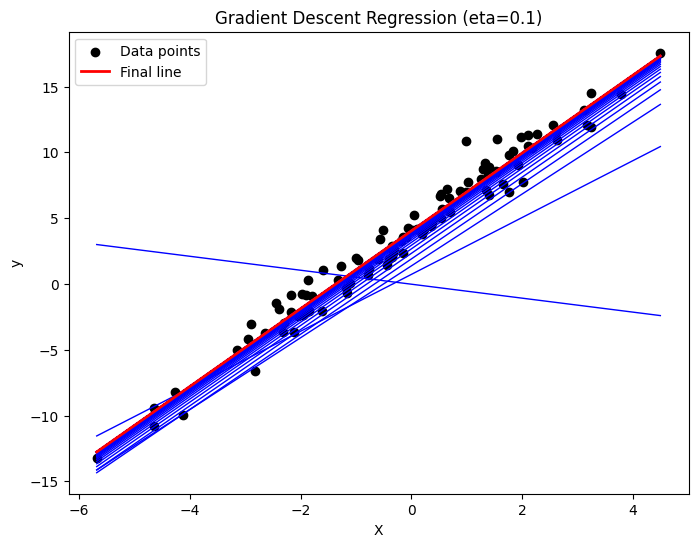

In [8]:
# Suite exercice

# Réaliser une fonction permettant de visualiser les différentes droites trouvées à chaque epoch. 
# Cette fonction doit avoir en argument eta
# Vous avez le droit de vous faire assister par IA

def plot_training_lines(X, y, eta=0.1, n_epochs=100):
    m = X.shape[0]

    # Add bias term
    X_b = torch.hstack([X, torch.ones((m, 1))])

    # Initialize random theta
    thetas = torch.randn(2, 1)

    # Store all theta values
    all_thetas = [thetas.clone()]

    for i in range(n_epochs):
        gradients = 2/m * torch.matmul(X_b.T, torch.matmul(X_b, thetas)-y)
        thetas = thetas - eta * gradients
        all_thetas.append(thetas.clone())

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X.numpy(), y.numpy(), c="black", label="Data points")

    # x values for plotting lines
    x_vals = torch.linspace(X.min(), X.max(), 100).reshape(-1,1)
    x_vals_b = torch.hstack([x_vals, torch.ones((x_vals.shape[0],1))])

    # Plot all intermediate lines in blue
    for theta in all_thetas[:-1]:
        y_vals = torch.matmul(x_vals_b, theta)
        plt.plot(x_vals.numpy(), y_vals.numpy(), color="blue", linewidth=1)

    # Plot last line in red (thicker)
    final_theta = all_thetas[-1]
    print(final_theta)
    y_vals_final = torch.matmul(x_vals_b, final_theta)
    plt.plot(x_vals.numpy(), y_vals_final.numpy(), color="red", linewidth=2, label="Final line")

    plt.title(f"Gradient Descent Regression (eta={eta})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()


plot_training_lines(X, y, eta=0.1, n_epochs=100)

tensor([[3.0529],
        [4.0696]])


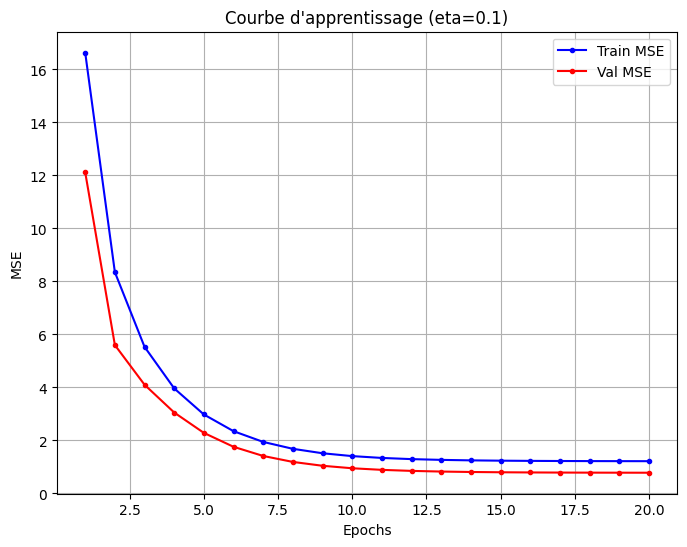

tensor([[3.0529],
        [4.0696]])

In [ ]:
# Suite exercice

# Réaliser une fonction permettant d'afficher la courbe d'apprentissage.
# Bonus: split train/val afin de visualiser les deux courbes
# Vous avez le droit de vous faire assister par IA

import torch
import matplotlib.pyplot as plt

m = 100
X = 2 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)


def plot_learning_curve(X, y, eta=0.1, n_epochs=100, val_split=0.2):
    """
    Affiche la courbe d'apprentissage (erreur train/val) pour une régression linéaire
    avec descente de gradient.

    Args:
        X (torch.Tensor): Données d'entrée, shape (m,1)
        y (torch.Tensor): Cibles, shape (m,1)
        eta (float): Learning rate
        n_epochs (int): Nombre d'itérations
        val_split (float): Pourcentage de validation (0-1)
    """
    m = X.shape[0]

    # --- Split train / validation ---
    val_size = int(m * val_split)
    idx = torch.randperm(m)  # shuffle
    val_idx = idx[:val_size]
    train_idx = idx[val_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Ajout du biais
    X_train_b = torch.hstack([X_train, torch.ones((X_train.shape[0], 1))])
    X_val_b   = torch.hstack([X_val,   torch.ones((X_val.shape[0], 1))])

    # Initialisation des paramètres
    thetas = torch.randn(X_train_b.shape[1],1)

    # Historique des erreurs
    train_errors = []
    val_errors = []

    for epoch in range(n_epochs):
        # --- Forward ---
        y_pred = X_train_b @ thetas
        error = y_pred - y_train

        # --- Gradient ---
        gradients = 2 / X_train.shape[0] * (X_train_b.T @ error)
        thetas -= eta * gradients

        # --- Loss train ---
        train_mse = torch.mean((y_train - X_train_b @ thetas)**2).item()
        train_errors.append(train_mse)

        # --- Loss val ---
        val_mse = torch.mean((y_val - X_val_b @ thetas)**2).item()
        val_errors.append(val_mse)

    # --- Plot courbes ---
    print(thetas)
    plt.figure(figsize=(8,6))
    plt.plot(range(1, n_epochs+1), train_errors, label="Train MSE", color="blue", marker='.')
    plt.plot(range(1, n_epochs+1), val_errors, label="Val MSE", color="red", marker='.')
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title(f"Courbe d'apprentissage (eta={eta})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return thetas
plot_learning_curve(X, y, eta=10, n_epochs=20, val_split=0.1)

In [10]:
X.shape

torch.Size([100, 1])

In [11]:
y

tensor([[ 11.1746],
        [  5.5251],
        [  5.5407],
        [  4.9077],
        [ 15.9201],
        [ 18.6645],
        [  1.3786],
        [ -1.6402],
        [ -2.8322],
        [ -3.2297],
        [ -0.6088],
        [ 10.6167],
        [ -3.3380],
        [ 12.8116],
        [  3.7365],
        [  4.6211],
        [  5.5737],
        [  5.2160],
        [ -4.0301],
        [-14.5617],
        [  5.9815],
        [ -2.5600],
        [  2.4104],
        [  5.1871],
        [ -5.9631],
        [ -0.7496],
        [ -9.5395],
        [  9.1738],
        [  0.7564],
        [  2.3502],
        [  8.1579],
        [-11.5320],
        [ 11.9069],
        [  9.3502],
        [ 10.5569],
        [  4.3672],
        [ -0.8911],
        [  8.7494],
        [  3.0297],
        [  3.3330],
        [ -1.0477],
        [  4.4423],
        [  5.4142],
        [  7.1042],
        [  4.9822],
        [  2.2120],
        [  1.1144],
        [  4.9958],
        [  1.4471],
        [ -0.5325],


# Intérêt de la mise à l'échelle

In [12]:
m = 100

X1 = 2 * torch.rand(m, 1)
X2 = 100 * torch.rand(m, 1)

X = torch.cat([X1, X2], dim=1)
X_scaled = torch.cat([(X1 - X1.mean(axis=0) )/ X1.std(axis=0), (X2 - X2.mean(axis=0) )/ X2.std(axis=0)], dim=1)

# Biais = 15.5, Poids de X1 = 2, Poids de X2 = 5.6
y = 15.5 + 2 * X1 + 5.6 * X2

# Faites tourner la fonction précédente sur ces nouvelles données,
# puis comparez avec les mêmes données mises à l’échelle (StandardScaler).
# Que remarquez-vous ?

tensor([[nan],
        [nan],
        [nan]])


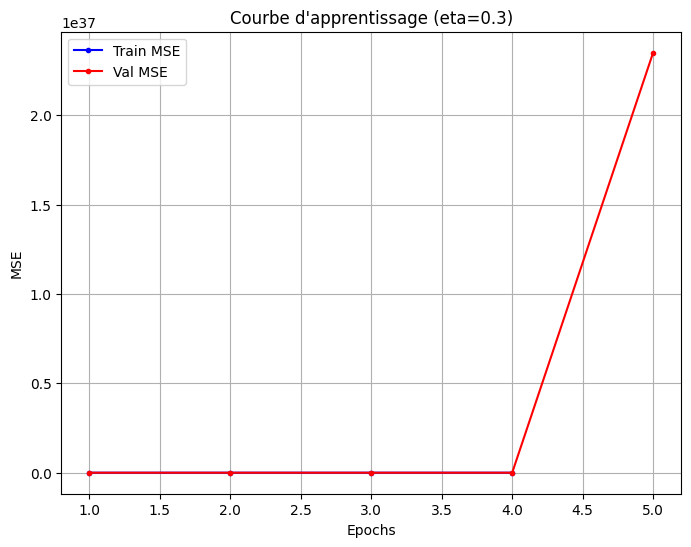

tensor([[nan],
        [nan],
        [nan]])

In [13]:
plot_learning_curve(X, y, eta=3e-1, n_epochs=50, val_split=0.1)

tensor([[  1.1444],
        [158.6810],
        [269.7300]])


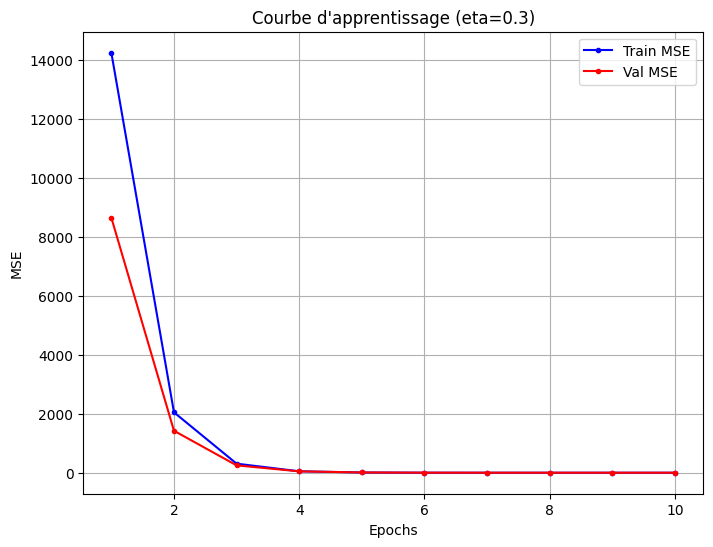

In [14]:
thetas = plot_learning_curve(X_scaled, y, eta=3e-1, n_epochs=10, val_split=0.1)

Le modèle entraîné sur `X_scaled` a trouvé cette équation :

$$ y = \theta'_1 \left( \frac{X_1 - \mu_1}{\sigma_1} \right) + \theta'_2 \left( \frac{X_2 - \mu_2}{\sigma_2} \right) + \theta'_{biais} $$

Si on développe pour isoler $X_1$ et $X_2$, on obtient l'équation sur les variables d'origine :

$$ y = \left( \frac{\theta'_1}{\sigma_1} \right) X_1 + \left( \frac{\theta'_2}{\sigma_2} \right) X_2 + \left( \theta'_{biais} - \frac{\theta'_1 \mu_1}{\sigma_1} - \frac{\theta'_2 \mu_2}{\sigma_2} \right) $$

In [ ]:
# Pour passer des paramètres trouvés sur les données mise à l'échelle à ceux d'origine il faut : 
mu1, std1 = X1.mean().item(), X1.std().item()
mu2, std2 = X2.mean().item(), X2.std().item()

theta1_scaled = thetas[0]    # Poids pour X1_scaled
theta2_scaled = thetas[1] # Poids pour X2_scaled
bias_scaled   = thetas[2]  # Biais_scaled (dernier élément de thetas)

# 1. Conversion des poids
theta1_orig = theta1_scaled / std1
theta2_orig = theta2_scaled / std2

# 2. Conversion du biais
bias_orig = bias_scaled - (theta1_orig * mu1) - (theta2_orig * mu2)

print(f"Poids d'origine reconstitués :")
print(f"Poids X1 : {theta1_orig.item():.2f} (Attendu : ~2.0)")
print(f"Poids X2 : {theta2_orig.item():.2f} (Attendu : ~5.6)")
print(f"Biais    : {bias_orig.item():.2f} (Attendu : ~15.5)")

Poids d'origine reconstitués :
Poids X1 : 2.05 (Attendu : ~2.0)
Poids X2 : 5.60 (Attendu : ~5.6)
Biais    : 15.42 (Attendu : ~15.5)


### Stochastic Gradient Descent

In [16]:
# Exerice : Adapter la batch gradient descente à la stochastic gradient descent

m = 100
X = 5 * torch.randn(m, 1)
y = 4 + 3 * X + torch.randn(m, 1)
X_b = torch.hstack([X, torch.ones((m, 1))])

eta = 0.01
n_epochs = 100

thetas = torch.randn(2, 1)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for idx in idx_shuffled:
        gradients = 2 * torch.matmul(X_b[idx, None].T, torch.matmul(X_b[idx, None], thetas)-y[idx, :])
        thetas = thetas - eta*gradients
    print(thetas)

tensor([[2.9039],
        [3.5400]])
tensor([[2.2370],
        [4.1733]])
tensor([[3.1271],
        [4.2613]])
tensor([[2.6825],
        [4.5318]])
tensor([[3.1736],
        [4.3677]])
tensor([[3.1985],
        [4.3204]])
tensor([[3.0976],
        [4.2959]])
tensor([[2.5849],
        [4.0738]])
tensor([[3.0278],
        [4.0307]])
tensor([[3.0768],
        [4.1772]])
tensor([[2.9737],
        [4.1810]])
tensor([[2.7233],
        [4.1531]])
tensor([[2.9434],
        [3.9948]])
tensor([[3.0359],
        [4.1298]])
tensor([[3.0986],
        [4.5036]])
tensor([[2.9546],
        [4.0416]])
tensor([[4.1201],
        [4.0974]])
tensor([[2.8615],
        [4.1762]])
tensor([[4.4200],
        [4.0503]])
tensor([[3.2219],
        [4.0226]])
tensor([[2.7409],
        [3.9991]])
tensor([[3.1324],
        [4.4039]])
tensor([[3.4268],
        [4.0795]])
tensor([[2.1601],
        [4.2102]])
tensor([[2.9555],
        [4.1434]])
tensor([[3.0714],
        [4.0996]])
tensor([[3.2096],
        [4.3587]])
t

Thetas trouvés : 
 tensor([[2.9164],
        [3.7685]])


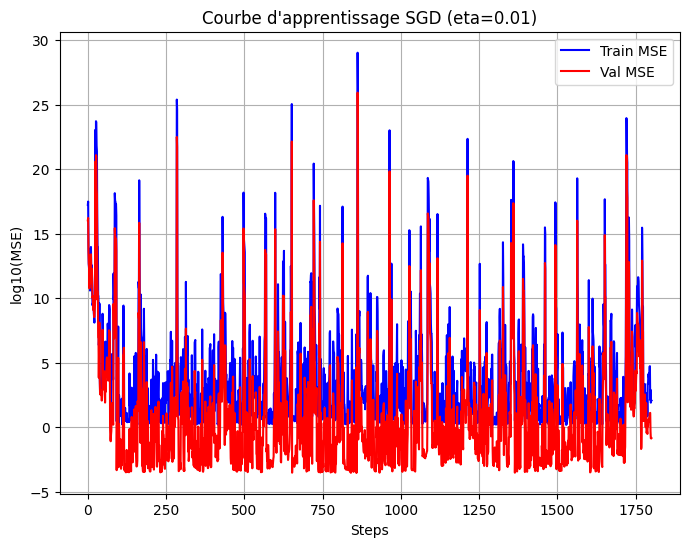

In [ ]:
def plot_learning_curve_SGD(X, y, eta=0.1, n_epochs=100, val_split=0.2):
    """
    Affiche la courbe d'apprentissage (erreur train/val) pour une régression linéaire
    avec descente de gradient stochastique (SGD).

    Args:
        X (torch.Tensor): Données d'entrée, shape (m, n)
        y (torch.Tensor): Cibles, shape (m, 1)
        eta (float): Learning rate
        n_epochs (int): Nombre d'itérations sur tout le dataset
        val_split (float): Pourcentage de validation (0-1)
    """
    m = X.shape[0]

    # --- Split train / validation ---
    val_size = int(m * val_split)
    idx = torch.randperm(m)  # shuffle
    val_idx = idx[:val_size]
    train_idx = idx[val_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Ajout du biais
    X_train_b = torch.hstack([X_train, torch.ones((X_train.shape[0], 1))])
    X_val_b   = torch.hstack([X_val,   torch.ones((X_val.shape[0], 1))])

    # Initialisation des paramètres
    thetas = torch.randn(X_train_b.shape[1], 1)

    # Historique des erreurs
    train_errors = []
    
    val_errors = []

    n_steps = 0
    for _ in range(n_epochs):
        idx_shuffled = torch.randperm(X_train_b.shape[0])
        for idx in idx_shuffled:
            n_steps += 1
            
            # Extraction d'une seule instance (le None permet de garder la dimension 2D)
            xi = X_train_b[idx, None]
            yi = y_train[idx, None]
            
            # --- Forward ---
            y_pred = xi @ thetas
            error = y_pred - yi

            # --- Gradient Stochastique ---
            # Suppression de la ligne erronée contenant X_b
            gradients = 2 * (xi.T @ error)
            thetas -= eta * gradients

            # --- Loss train ---
            # Attention: calculer la MSE complète à chaque step ralentit beaucoup l'exécution, 
            # mais c'est utile ici pour tracer la courbe détaillée
            train_mse = torch.mean((y_train - X_train_b @ thetas)**2).item()
            train_errors.append(train_mse)

            # --- Loss val ---
            val_mse = torch.mean((y_val - X_val_b @ thetas)**2).item()
            val_errors.append(val_mse)

    # --- Plot courbes ---
    print("Thetas trouvés : \n", thetas)
    
    plt.figure(figsize=(8,6))
    
    plt.plot(range(1, n_steps+1), 10*torch.log10(torch.tensor(train_errors)+1e-7), label="Train MSE", color="blue")
    plt.plot(range(1, n_steps+1), 10*torch.log10(torch.tensor(val_errors)+1e-7), label="Val MSE", color="red")
    plt.xlabel("Steps")
    plt.ylabel("log10(MSE)")
    plt.title(f"Courbe d'apprentissage SGD (eta={eta})")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve_SGD(X, y, eta=0.01, n_epochs=20, val_split=0.1)

### Mini-Batch Gradient Descent

In [18]:
# Exerice : Adapter la stochastic gradient descente à la mini-batch gradient descent

batch_size = 32

thetas = torch.randn(2, 1)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for i in range(m//batch_size):
        idx_start = i * batch_size
        idx_end = (i+1)*batch_size
        gradients = 2/batch_size * torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :].T, torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :], thetas)-y[idx_shuffled[idx_start:idx_end], :])
        thetas = thetas - eta*gradients
    print(thetas)

tensor([[3.0721],
        [0.0135]])
tensor([[3.0661],
        [0.2555]])
tensor([[3.0751],
        [0.4831]])
tensor([[3.0834],
        [0.6984]])
tensor([[3.1171],
        [0.8998]])
tensor([[3.0252],
        [1.0867]])
tensor([[2.9585],
        [1.2635]])
tensor([[3.0330],
        [1.4408]])
tensor([[3.0537],
        [1.5974]])
tensor([[3.0274],
        [1.7477]])
tensor([[3.0530],
        [1.8868]])
tensor([[3.0674],
        [2.0216]])
tensor([[3.0584],
        [2.1435]])
tensor([[3.1138],
        [2.2614]])
tensor([[3.0084],
        [2.3716]])
tensor([[3.0237],
        [2.4746]])
tensor([[3.0774],
        [2.5731]])
tensor([[2.9802],
        [2.6642]])
tensor([[3.0249],
        [2.7515]])
tensor([[3.0157],
        [2.8335]])
tensor([[3.0253],
        [2.9095]])
tensor([[3.0514],
        [2.9846]])
tensor([[3.0105],
        [3.0517]])
tensor([[3.0030],
        [3.1147]])
tensor([[2.9878],
        [3.1742]])
tensor([[3.0317],
        [3.2292]])
tensor([[3.0443],
        [3.2822]])
t

# Logistic Regression

In [18]:
from sklearn.datasets import load_breast_cancer
import torch
X, y = load_breast_cancer(as_frame=True, return_X_y=True)

In [19]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [20]:
import numpy as np
np.unique(y, return_counts=True)

(array([0, 1]), array([212, 357]))

In [21]:
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32)

In [22]:
X

tensor([[1.7990e+01, 1.0380e+01, 1.2280e+02,  ..., 2.6540e-01, 4.6010e-01,
         1.1890e-01],
        [2.0570e+01, 1.7770e+01, 1.3290e+02,  ..., 1.8600e-01, 2.7500e-01,
         8.9020e-02],
        [1.9690e+01, 2.1250e+01, 1.3000e+02,  ..., 2.4300e-01, 3.6130e-01,
         8.7580e-02],
        ...,
        [1.6600e+01, 2.8080e+01, 1.0830e+02,  ..., 1.4180e-01, 2.2180e-01,
         7.8200e-02],
        [2.0600e+01, 2.9330e+01, 1.4010e+02,  ..., 2.6500e-01, 4.0870e-01,
         1.2400e-01],
        [7.7600e+00, 2.4540e+01, 4.7920e+01,  ..., 0.0000e+00, 2.8710e-01,
         7.0390e-02]])

In [23]:
X_b = torch.hstack([(X - X.mean(axis=0)) / X.std(axis=0), torch.ones(X.shape[0], 1)])

X_b.shape

torch.Size([569, 31])

In [ ]:
# Exercice : Modifier la linear regression pour réaliser de la logistic regression
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

m = 100
n_epochs = 50
eta = 0.1
batch_size = 16
num_features = X_b.shape[1]
thetas = torch.randn(num_features, 1)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for i in range(m//batch_size):
        idx_start = i * batch_size
        idx_end = (i+1)*batch_size
        gradients = 1/batch_size * torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :].T, sigmoid(torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :], thetas))-y[idx_shuffled[idx_start:idx_end], None])
        thetas = thetas - eta*gradients
    print(thetas)

tensor([[-0.3721],
        [ 0.5334],
        [-2.2013],
        [ 0.6993],
        [-0.2016],
        [ 0.7743],
        [ 1.4149],
        [-0.2909],
        [-0.4698],
        [ 0.3162],
        [-1.2899],
        [-0.4781],
        [-1.0447],
        [ 0.4109],
        [ 0.0994],
        [-1.1031],
        [-1.3056],
        [-0.3176],
        [ 0.0043],
        [ 0.4177],
        [-0.9807],
        [-0.6928],
        [ 0.6533],
        [-0.9777],
        [ 1.1934],
        [-2.3290],
        [ 1.4097],
        [-0.6072],
        [ 1.3114],
        [ 0.4199],
        [ 0.2396]])
tensor([[-0.3624],
        [ 0.4722],
        [-2.1983],
        [ 0.7165],
        [-0.3282],
        [ 0.6674],
        [ 1.3450],
        [-0.3611],
        [-0.5550],
        [ 0.2015],
        [-1.2667],
        [-0.4361],
        [-1.0237],
        [ 0.4327],
        [ 0.1250],
        [-1.1308],
        [-1.3030],
        [-0.3121],
        [ 0.0272],
        [ 0.4012],
        [-1.0000],
        [-0

In [44]:
(((X_b @ thetas > 0.5) * 1.0 == y[..., None]) * 1.0).mean() * 100

tensor(91.5641)

# Softmax Regression

In [46]:
from sklearn.datasets import load_iris
import torch

X, y = load_iris(as_frame=True, return_X_y=True)

In [47]:
device = "cpu"

In [48]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [50]:
y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [4]:
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.int64).to(device)

X_b = torch.hstack([(X - X.mean(axis=0)) / X.std(axis=0), torch.ones(X.shape[0], 1)]).to(device)
X_b.shape

torch.Size([150, 5])

In [5]:
y

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

In [6]:
num_features = X_b.shape[1]
num_classes = torch.unique(y).shape[0]

In [32]:
y = torch.nn.functional.one_hot(y, num_classes=num_classes).float()

In [33]:
def softmax(x): 
    exp_x = torch.exp(x) 
    return exp_x / exp_x.sum(axis=1)[..., None]

batch_size = 16
eta = 1e-1
n_epochs = 10000
m = X_b.shape[0]
thetas = torch.randn(num_features, num_classes).to(device)
for i in range(n_epochs):
    idx_shuffled = torch.randperm(m)
    for i in range(m//batch_size):
        idx_start = i * batch_size
        idx_end = (i+1)*batch_size
        p_hat = softmax(torch.matmul(X_b[idx_shuffled[idx_start:idx_end], :], thetas))
        gradients = 1/batch_size * X_b[idx_shuffled[idx_start:idx_end], :].T @ (p_hat - y[idx_shuffled[idx_start:idx_end], :])
        thetas = thetas - eta*gradients
    # print(thetas)

    print(round(((torch.argmax((X_b @ thetas), dim=-1) == torch.argmax(y, dim=-1)) * 1.0).mean().item() * 100, 2))  # métriques !
    

62.67
68.0
80.0
86.0
88.67
90.67
91.33
91.33
92.67
92.67
92.67
92.67
92.67
92.67
92.67
93.33
92.67
92.67
93.33
93.33
93.33
94.0
94.0
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
94.67
95.33
95.33
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
96.0
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
97.33
9